In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from python_utils.visualization_utils import perc, SetPlotRC, ApplyFont, format_results_for_jupyter_and_latex, print_experiment_summary_hyperparams
from python_utils.visualization_utils import plot_pcl_convergence_ci, plot_pcl_convergence_w_quantiles, plot_pcl_convergence_boxplot

import warnings
warnings.filterwarnings("ignore")

In [3]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

In [4]:
import glob
import pandas as pd
import numpy as np

# Adjust this path if needed
# csv_files = sorted(glob.glob("../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_*_n2000_array_2791425.csv"))

csv_files = sorted(glob.glob("../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_*_n5000_array_2792533.csv"))

csv_files

['../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_1_n5000_array_2792533.csv',
 '../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_2_n5000_array_2792533.csv',
 '../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_3_n5000_array_2792533.csv',
 '../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_4_n5000_array_2792533.csv',
 '../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_5_n5000_array_2792533.csv',
 '../Results/Proxy_Misspecification_6Settings/proxy_misspecification_setting_6_n5000_array_2792533.csv']

In [5]:
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Optional: keep only successful runs if your CSV has an Error column
if "Error" in df.columns:
    df = df[df["Error"].isna() | (df["Error"].astype(str).str.len() == 0)].copy()

df["Setting"] = df["Setting"].astype(int)
df["Data_Size"] = df["Data_Size"].astype(int)
df["Seed"] = df["Seed"].astype(int)

df.head()

,Algorithm,Setting,Scenario,Data_Size,Seed,Causal_MSE,Estimated_Response,Treatment_Grid,Ground_Truth_Response,Error,Inlier_Ratio
0,OutcomeNet,1,setting_1,5000,0,0.003185,"[1.1079093217849731, 1.0373132228851318, 0.960...","[0.04313457527273254, 0.15379537817508407, 0.2...","[1.1092735313229658, 1.0848741241464661, 1.033...",NaN,1.0
1,TreatmentNet,1,setting_1,5000,0,0.003231,"[1.1598789691925049, 1.050431251525879, 0.9388...","[0.04313457527273254, 0.15379537817508407, 0.2...","[1.1092735313229658, 1.0848741241464661, 1.033...",NaN,1.0
2,DRNet_V1,1,setting_1,5000,0,0.002100,"[1.0629898309707642, 0.9920359253883362, 0.914...","[0.04313457527273254, 0.15379537817508407, 0.2...","[1.1092735313229658, 1.0848741241464661, 1.033...",NaN,1.0
3,DRNet_V2,1,setting_1,5000,0,0.003075,"[0.9495875835418701, 0.9050956964492798, 0.853...","[0.04313457527273254, 0.15379537817508407, 0.2...","[1.1092735313229658, 1.0848741241464661, 1.033...",NaN,1.0
4,DRKPV,1,setting_1,5000,0,0.004367,"[1.113314151763916, 1.0558052062988281, 0.9769...","[0.04313457527273254, 0.15379537817508407, 0.2...","[1.1092735313229658, 1.0848741241464661, 1.033...",NaN,1.0


In [6]:
mse_summary = (
    df.groupby(["Setting", "Algorithm"])
      .agg(
          mean_mse=("Causal_MSE", "mean"),
          se_mse=("Causal_MSE", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
          median_mse=("Causal_MSE", "median"),
          n_runs=("Causal_MSE", "count"),
      )
      .reset_index()
)

mse_summary

,Setting,Algorithm,mean_mse,se_mse,median_mse,n_runs
0,1,DRKPV,0.004570,0.000709,0.003769,10
1,1,DRNet_V1,0.003025,0.000600,0.002835,10
2,1,DRNet_V2,0.001895,0.000326,0.001624,10
3,1,KPV,0.006767,0.000779,0.006255,10
4,1,KernelAlternativeProxy,0.002428,0.000539,0.001994,10
5,1,OutcomeNet,0.004372,0.000615,0.004181,10
6,1,TreatmentNet,0.004087,0.000509,0.003866,10
7,2,DRKPV,0.009953,0.000696,0.009929,10
8,2,DRNet_V1,0.007663,0.000854,0.007696,10
9,2,DRNet_V2,0.008359,0.001316,0.007376,10


In [7]:
mse_summary["mean ± se"] = mse_summary.apply(
    lambda r: f"{r['mean_mse']:.4g} ± {r['se_mse']:.2g}",
    axis=1,
)

mse_table = mse_summary.pivot_table(
    index="Setting",
    columns="Algorithm",
    values="mean ± se",
    aggfunc="first",
)

mse_table

Algorithm,DRKPV,DRNet_V1,DRNet_V2,KPV,KernelAlternativeProxy,OutcomeNet,TreatmentNet
Setting,,,,,,,
1,0.00457 ± 0.00071,0.003025 ± 0.0006,0.001895 ± 0.00033,0.006767 ± 0.00078,0.002428 ± 0.00054,0.004372 ± 0.00062,0.004087 ± 0.00051
2,0.009953 ± 0.0007,0.007663 ± 0.00085,0.008359 ± 0.0013,0.007549 ± 0.00074,0.01257 ± 0.0014,0.007375 ± 0.0009,0.006276 ± 0.0011
3,0.004141 ± 0.0005,0.003158 ± 0.00054,0.001765 ± 0.00021,0.00588 ± 0.00056,0.001275 ± 0.00018,0.004643 ± 0.0011,0.004713 ± 0.00041
4,0.01821 ± 0.0027,0.01198 ± 0.002,0.02357 ± 0.0044,0.0132 ± 0.0019,0.01809 ± 0.0015,0.01348 ± 0.0018,0.02369 ± 0.0036
5,0.008311 ± 0.0022,0.005924 ± 0.0016,0.004081 ± 0.0011,0.01981 ± 0.005,0.003635 ± 0.00062,0.008571 ± 0.0017,0.00738 ± 0.0018
6,0.2292 ± 0.05,0.1586 ± 0.025,0.1082 ± 0.022,0.1535 ± 0.031,0.1919 ± 0.021,0.1631 ± 0.032,0.09443 ± 0.022


In [8]:
best_by_setting = (
    mse_summary.sort_values(["Setting", "mean_mse"])
    .groupby("Setting")
    .first()
    [["Algorithm", "mean_mse", "se_mse", "n_runs"]]
)

best_by_setting

,Algorithm,mean_mse,se_mse,n_runs
Setting,,,,
1,DRNet_V2,0.001895,0.000326,10
2,TreatmentNet,0.006276,0.001058,10
3,KernelAlternativeProxy,0.001275,0.000176,10
4,DRNet_V1,0.011978,0.002030,10
5,KernelAlternativeProxy,0.003635,0.000618,10
6,TreatmentNet,0.094431,0.022373,10


# Misspecification in Synthetic Low Dim ATE

In [9]:
# ==========================================
# Cell 1: Compact misspecification MSE table
# ==========================================
import numpy as np
import pandas as pd
from IPython.display import display

CSV_PATH = "../Results/Synthetic_Low_Dim_Misspecification_Experiment/DRPCLNET_SyntheticLowDim_Misspecification_Summary_N5000_2026-04-25_14-57-09.csv"
DATA_SIZE = 5000

scenario_order = [
    "outcome_head_jitter_std_0.2",
    "outcome_head_jitter_std_0.5",
    "treatment_head_jitter_std_0.2",
    "treatment_head_jitter_std_0.5",
]

scenario_labels = {
    "outcome_head_jitter_std_0.2": r"Outcome misspec. ($\sigma=0.2$)",
    "outcome_head_jitter_std_0.5": r"Outcome misspec. ($\sigma=0.5$)",
    "treatment_head_jitter_std_0.2": r"Treatment misspec. ($\sigma=0.2$)",
    "treatment_head_jitter_std_0.5": r"Treatment misspec. ($\sigma=0.5$)",
}

algo_order = [
    "DRPCLNET_Version1",
    "DRPCLNET_Version2",
    "OutcomeBridgePCLNET",
    "TreatmentBridgePCLNET",
]

algo_labels = {
    "DRPCLNET_Version1": "DRPCLNET (V1)",
    "DRPCLNET_Version2": "DRPCLNET (V2)",
    "OutcomeBridgePCLNET": "OutcomeBridgeNet",
    "TreatmentBridgePCLNET": "TreatmentBridgeNet",
}

df = pd.read_csv(CSV_PATH)

# robust to either column name
size_col = "Data_Size" if "Data_Size" in df.columns else "Data_Size_Requested"

df = df[df[size_col] == DATA_SIZE].copy()
df = df[df["Scenario"].isin(scenario_order)].copy()

summary = (
    df.groupby(["Scenario", "Algorithm"])["Causal_MSE"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]
summary["mean_pm_ci"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['ci95']:.4f}", axis=1
)

mse_table = (
    summary.pivot(index="Scenario", columns="Algorithm", values="mean_pm_ci")
           .reindex(index=scenario_order, columns=algo_order)
           .rename(index=scenario_labels, columns=algo_labels)
)

display(mse_table)

# Optional: LaTeX-ready table
print(mse_table.to_latex(escape=False))

Algorithm,DRPCLNET (V1),DRPCLNET (V2),OutcomeBridgeNet,TreatmentBridgeNet
Scenario,,,,
Outcome misspec. ($\sigma=0.2$),0.0170 ± 0.0030,0.0167 ± 0.0034,0.2546 ± 0.0871,0.1301 ± 0.0124
Outcome misspec. ($\sigma=0.5$),0.0203 ± 0.0053,0.0221 ± 0.0054,1.3719 ± 0.5401,0.1301 ± 0.0124
Treatment misspec. ($\sigma=0.2$),0.0172 ± 0.0028,0.0156 ± 0.0029,0.0232 ± 0.0040,0.2408 ± 0.0534
Treatment misspec. ($\sigma=0.5$),0.0178 ± 0.0030,0.0159 ± 0.0030,0.0232 ± 0.0040,0.9024 ± 0.3635


\begin{tabular}{lllll}
\toprule
Algorithm & DRPCLNET (V1) & DRPCLNET (V2) & OutcomeBridgeNet & TreatmentBridgeNet \\
Scenario &  &  &  &  \\
\midrule
Outcome misspec. ($\sigma=0.2$) & 0.0170 ± 0.0030 & 0.0167 ± 0.0034 & 0.2546 ± 0.0871 & 0.1301 ± 0.0124 \\
Outcome misspec. ($\sigma=0.5$) & 0.0203 ± 0.0053 & 0.0221 ± 0.0054 & 1.3719 ± 0.5401 & 0.1301 ± 0.0124 \\
Treatment misspec. ($\sigma=0.2$) & 0.0172 ± 0.0028 & 0.0156 ± 0.0029 & 0.0232 ± 0.0040 & 0.2408 ± 0.0534 \\
Treatment misspec. ($\sigma=0.5$) & 0.0178 ± 0.0030 & 0.0159 ± 0.0030 & 0.0232 ± 0.0040 & 0.9024 ± 0.3635 \\
\bottomrule
\end{tabular}



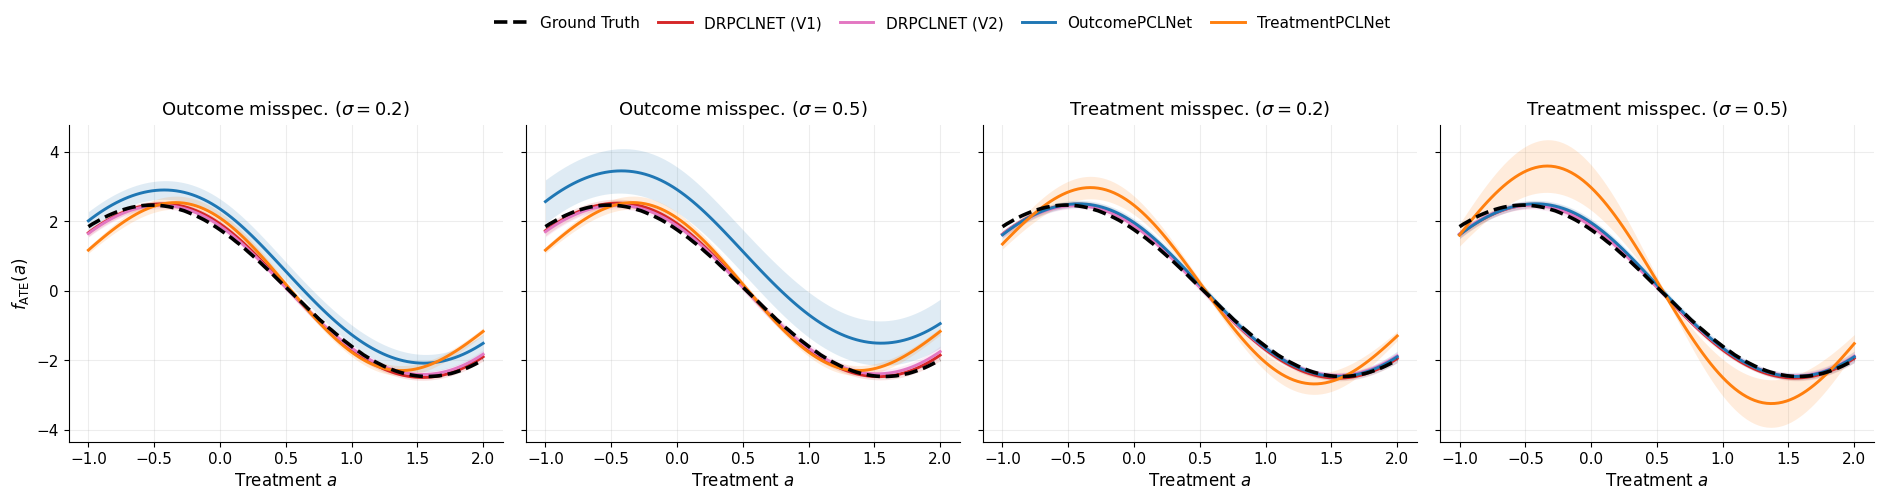

In [10]:
# ==========================================
# Cell 2: Main-text 1x4 misspecification panel
# ==========================================
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PKL_PATH = "../Results/Synthetic_Low_Dim_Misspecification_Experiment/DRPCLNET_SyntheticLowDim_Misspecification_Full_N5000_2026-04-25_14-57-09.pkl"
DATA_SIZE = 5000

scenario_order = [
    "outcome_head_jitter_std_0.2",
    "outcome_head_jitter_std_0.5",
    "treatment_head_jitter_std_0.2",
    "treatment_head_jitter_std_0.5",
]

scenario_labels = {
    "outcome_head_jitter_std_0.2": r"Outcome misspec. ($\sigma=0.2$)",
    "outcome_head_jitter_std_0.5": r"Outcome misspec. ($\sigma=0.5$)",
    "treatment_head_jitter_std_0.2": r"Treatment misspec. ($\sigma=0.2$)",
    "treatment_head_jitter_std_0.5": r"Treatment misspec. ($\sigma=0.5$)",
}

# --- Global Configuration ---
LEGEND_ORDER = [
    "DRPCLNET (V1)",
    "DRPCLNET (V2)",
    "OutcomePCLNet",
    "TreatmentPCLNet",
    "PKDR",
    "DRKPV",
    "KPV",
]

COLOR_PALETTE = {
    "DRPCLNET (V1)": "#d62728",   # Red
    "DRPCLNET (V2)": "#e377c2",   # Pink
    "OutcomePCLNet": "#1f77b4",   # Blue
    "TreatmentPCLNet": "#ff7f0e", # Orange
    "PKDR": "#7f7f7f",            # Gray
    "DRKPV": "#2ca02c",           # Green
    "KPV": "#9467bd",             # Purple
}

# Raw names in dataframe -> display names used in the paper
algo_name_map = {
    "DRPCLNET_Version1": "DRPCLNET (V1)",
    "DRPCLNET_Version2": "DRPCLNET (V2)",
    "OutcomeBridgePCLNET": "OutcomePCLNet",
    "TreatmentBridgePCLNET": "TreatmentPCLNet",
}

algo_order_raw = [
    "DRPCLNET_Version1",
    "DRPCLNET_Version2",
    "OutcomeBridgePCLNET",
    "TreatmentBridgePCLNET",
]

def find_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def to_numpy_array(x):
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, (list, tuple)):
        return np.asarray(x, dtype=float)
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                return np.asarray(ast.literal_eval(x), dtype=float)
            except Exception:
                pass
        return np.fromstring(
            x.replace("[", "").replace("]", "").replace(",", " "),
            sep=" "
        )
    return np.asarray(x, dtype=float)

# ----------------------------
# Load data
# ----------------------------
df_full = pd.read_pickle(PKL_PATH)

size_col = "Data_Size" if "Data_Size" in df_full.columns else "Data_Size_Requested"
df_full = df_full[df_full[size_col] == DATA_SIZE].copy()
df_full = df_full[df_full["Scenario"].isin(scenario_order)].copy()

grid_col = find_first_existing_column(df_full, ["Dose_Response_Grid", "Treatment_Grid", "do_A", "grid"])
true_col = find_first_existing_column(df_full, ["True_Curve", "EY_do_A", "true_curve"])
est_col  = find_first_existing_column(df_full, ["Estimated_Curve", "estimated_curve"])

if grid_col is None or true_col is None or est_col is None:
    raise ValueError(
        f"Could not find curve columns. Found grid={grid_col}, true={true_col}, est={est_col}.\n"
        "Check your saved dataframe column names."
    )

for col in [grid_col, true_col, est_col]:
    df_full[col] = df_full[col].apply(to_numpy_array)

# Keep only algorithms that appear in the data
available_algos = [a for a in algo_order_raw if a in df_full["Algorithm"].unique()]

# ----------------------------
# Plot styling
# ----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

legend_handles = {}
ground_truth_handle = None

for j, (ax, scenario) in enumerate(zip(axes, scenario_order)):
    sub = df_full[df_full["Scenario"] == scenario].copy()
    if sub.empty:
        ax.axis("off")
        continue

    # Ground-truth curve
    truth_stack = np.stack(sub[true_col].values, axis=0)
    truth_mean = truth_stack.mean(axis=0)
    grid = sub[grid_col].iloc[0]

    gt_line, = ax.plot(
        grid,
        truth_mean,
        linestyle="--",
        linewidth=2.6,
        color="black",
        label="Ground Truth",
        zorder=5,
    )
    if ground_truth_handle is None:
        ground_truth_handle = gt_line

    # Estimated curves by algorithm
    for algo_raw in available_algos:
        sub_algo = sub[sub["Algorithm"] == algo_raw]
        if sub_algo.empty:
            continue

        display_name = algo_name_map[algo_raw]
        color = COLOR_PALETTE[display_name]

        curves = np.stack(sub_algo[est_col].values, axis=0)
        mean_curve = curves.mean(axis=0)
        std_curve = curves.std(axis=0, ddof=1) if len(curves) > 1 else np.zeros_like(mean_curve)

        line, = ax.plot(
            grid,
            mean_curve,
            linewidth=2.1,
            color=color,
            label=display_name,
            zorder=4,
        )
        ax.fill_between(
            grid,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color,
            alpha=0.14,
            linewidth=0,
            zorder=3,
        )

        if display_name not in legend_handles:
            legend_handles[display_name] = line

    ax.set_title(scenario_labels[scenario], pad=8)
    ax.set_xlabel("Treatment $a$")
    if j == 0:
        ax.set_ylabel(r"$f_{\mathrm{ATE}}(a)$")
    ax.grid(alpha=0.22, linewidth=0.8)

# ----------------------------
# Single legend for the whole panel
# ----------------------------
final_handles = []
final_labels = []

if ground_truth_handle is not None:
    final_handles.append(ground_truth_handle)
    final_labels.append("Ground Truth")

for name in LEGEND_ORDER:
    if name in legend_handles:
        final_handles.append(legend_handles[name])
        final_labels.append(name)

fig.legend(
    final_handles,
    final_labels,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.10),
    columnspacing=1.2,
    handlelength=2.2,
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

# Optional save for paper
fig.savefig("Figures/misspecification_main_text_panel.pdf", bbox_inches="tight")
# fig.savefig("misspecification_main_text_panel.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
# # ==========================================
# # Cell 2: Simple 2x2 misspecification curves
# # Requires the full dataframe with curve arrays
# # (preferably the .pkl file, not the CSV)
# # ==========================================
# import ast
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# PKL_PATH = "../Results/Synthetic_Low_Dim_Misspecification_Experiment/DRPCLNET_SyntheticLowDim_Misspecification_Full_N5000_2026-04-25_14-57-09.pkl"
# DATA_SIZE = 5000

# scenario_order = [
#     "outcome_head_jitter_std_0.2",
#     "outcome_head_jitter_std_0.5",
#     "treatment_head_jitter_std_0.2",
#     "treatment_head_jitter_std_0.5",
# ]

# scenario_labels = {
#     "outcome_head_jitter_std_0.2": r"Outcome misspecified ($\sigma=0.2$)",
#     "outcome_head_jitter_std_0.5": r"Outcome misspecified ($\sigma=0.5$)",
#     "treatment_head_jitter_std_0.2": r"Treatment misspecified ($\sigma=0.2$)",
#     "treatment_head_jitter_std_0.5": r"Treatment misspecified ($\sigma=0.5$)",
# }

# algo_order = [
#     "DRPCLNET_Version1",
#     "DRPCLNET_Version2",
#     "OutcomeBridgePCLNET",
#     "TreatmentBridgePCLNET",
# ]

# algo_labels = {
#     "DRPCLNET_Version1": "DRPCLNET (V1)",
#     "DRPCLNET_Version2": "DRPCLNET (V2)",
#     "OutcomeBridgePCLNET": "OutcomeBridgeNet",
#     "TreatmentBridgePCLNET": "TreatmentBridgeNet",
# }

# # simple fixed colors for readability
# algo_colors = {
#     "DRPCLNET_Version1": "#d62728",
#     "DRPCLNET_Version2": "#ff9896",
#     "OutcomeBridgePCLNET": "#1f77b4",
#     "TreatmentBridgePCLNET": "#2ca02c",
# }

# def find_first_existing_column(df, candidates):
#     for c in candidates:
#         if c in df.columns:
#             return c
#     return None

# def to_numpy_array(x):
#     if isinstance(x, np.ndarray):
#         return x.astype(float)
#     if isinstance(x, (list, tuple)):
#         return np.asarray(x, dtype=float)
#     if isinstance(x, str):
#         x = x.strip()
#         if x.startswith("[") and x.endswith("]"):
#             try:
#                 return np.asarray(ast.literal_eval(x), dtype=float)
#             except Exception:
#                 pass
#         return np.fromstring(
#             x.replace("[", "").replace("]", "").replace(",", " "),
#             sep=" "
#         )
#     return np.asarray(x, dtype=float)

# df_full = pd.read_pickle(PKL_PATH)

# size_col = "Data_Size" if "Data_Size" in df_full.columns else "Data_Size_Requested"
# df_full = df_full[df_full[size_col] == DATA_SIZE].copy()
# df_full = df_full[df_full["Scenario"].isin(scenario_order)].copy()

# grid_col = find_first_existing_column(df_full, ["Dose_Response_Grid", "Treatment_Grid", "do_A", "grid"])
# true_col = find_first_existing_column(df_full, ["True_Curve", "EY_do_A", "true_curve"])
# est_col  = find_first_existing_column(df_full, ["Estimated_Curve", "estimated_curve"])

# if grid_col is None or true_col is None or est_col is None:
#     raise ValueError(
#         f"Could not find curve columns. Found grid={grid_col}, true={true_col}, est={est_col}.\n"
#         "Check your saved dataframe column names."
#     )

# for col in [grid_col, true_col, est_col]:
#     df_full[col] = df_full[col].apply(to_numpy_array)

# plt.rcParams.update({
#     "font.size": 11,
#     "axes.titlesize": 12,
#     "axes.labelsize": 11,
#     "legend.fontsize": 9,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
# })

# fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# axes = axes.ravel()

# for ax, scenario in zip(axes, scenario_order):
#     sub = df_full[df_full["Scenario"] == scenario].copy()
#     if sub.empty:
#         ax.axis("off")
#         continue

#     # ground truth
#     truth_stack = np.stack(sub[true_col].values, axis=0)
#     truth_mean = truth_stack.mean(axis=0)
#     grid = sub[grid_col].iloc[0]

#     ax.plot(grid, truth_mean, "k--", lw=2.5, label="Ground Truth")

#     for algo in algo_order:
#         sub_algo = sub[sub["Algorithm"] == algo]
#         if sub_algo.empty:
#             continue

#         curves = np.stack(sub_algo[est_col].values, axis=0)
#         mean_curve = curves.mean(axis=0)
#         std_curve = curves.std(axis=0, ddof=1) if len(curves) > 1 else np.zeros_like(mean_curve)

#         ax.plot(
#             grid,
#             mean_curve,
#             lw=2.0,
#             color=algo_colors[algo],
#             label=algo_labels[algo],
#         )
#         ax.fill_between(
#             grid,
#             mean_curve - std_curve,
#             mean_curve + std_curve,
#             color=algo_colors[algo],
#             alpha=0.16,
#         )

#     ax.set_title(scenario_labels[scenario])
#     ax.set_xlabel("Treatment $a$")
#     ax.set_ylabel(r"$f_{\mathrm{ATE}}(a)$")
#     ax.grid(alpha=0.25)

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="upper center",
#     ncol=3,
#     frameon=False,
#     bbox_to_anchor=(0.5, 1.02)
# )
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

# Misspecification in Synthetic CATE

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display

# =========================================================
# USER INPUT
# =========================================================
CSV_PATH = "../Results/CATE_Synthetic_Misspecification_Experiment/CATE_Misspecification_Summary_n5000_2026-04-25_14-57-09.csv"
DATA_SIZE = 5000
SCALE = 1e3   # use 1e3 to report "MSE x 10^3" as in the paper; set to 1.0 for raw MSE

# =========================================================
# LOAD + CLEAN
# =========================================================
df = pd.read_csv(CSV_PATH)

# Make types explicit
df["Data_Size_Requested"] = pd.to_numeric(df["Data_Size_Requested"], errors="coerce")
df["Jitter_STD"] = pd.to_numeric(df["Jitter_STD"], errors="coerce")
df["Causal_MSE"] = pd.to_numeric(df["Causal_MSE"], errors="coerce")

# Keep only misspecified CATE runs at the desired sample size
df_sub = df[
    (df["Data_Size_Requested"] == DATA_SIZE) &
    (df["Scenario"].isin(["outcome_misspecified", "treatment_misspecified"])) &
    (df["Jitter_STD"].isin([0.2, 0.5]))
].copy()

# Sanity check
print("Rows kept:", len(df_sub))
print("Scenarios:", sorted(df_sub["Scenario"].dropna().unique()))
print("Components:", sorted(df_sub["Misspecified_Component"].dropna().unique()))
print("Algorithms:", sorted(df_sub["Algorithm"].dropna().unique()))

# =========================================================
# LABELS / ORDER
# =========================================================
algo_order = [
    "DRPCLNET_Version1",
    "DRPCLNET_Version2",
    "OutcomeBridgePCLNET",
    "TreatmentBridgePCLNET",
]

algo_labels = {
    "DRPCLNET_Version1": "DRPCLNET (V1)",
    "DRPCLNET_Version2": "DRPCLNET (V2)",
    "OutcomeBridgePCLNET": "OutcomeBridgeNet",
    "TreatmentBridgePCLNET": "TreatmentBridgeNet",
}

scenario_labels = {
    ("outcome_misspecified", 0.2): r"Outcome misspecified ($\sigma=0.2$)",
    ("outcome_misspecified", 0.5): r"Outcome misspecified ($\sigma=0.5$)",
    ("treatment_misspecified", 0.2): r"Treatment misspecified ($\sigma=0.2$)",
    ("treatment_misspecified", 0.5): r"Treatment misspecified ($\sigma=0.5$)",
}

row_order = [
    r"Outcome misspecified ($\sigma=0.2$)",
    r"Outcome misspecified ($\sigma=0.5$)",
    r"Treatment misspecified ($\sigma=0.2$)",
    r"Treatment misspecified ($\sigma=0.5$)",
]

# =========================================================
# SUMMARY STATS
# =========================================================
summary = (
    df_sub.groupby(["Scenario", "Jitter_STD", "Algorithm"], as_index=False)["Causal_MSE"]
          .agg(mean="mean", std="std", count="count")
)

summary["se"] = summary["std"] / np.sqrt(summary["count"].clip(lower=1))
summary["ci95"] = 1.96 * summary["se"]

summary["mean_scaled"] = SCALE * summary["mean"]
summary["ci95_scaled"] = SCALE * summary["ci95"]

summary["Row_Label"] = [
    scenario_labels[(sc, js)] for sc, js in zip(summary["Scenario"], summary["Jitter_STD"])
]

# =========================================================
# PIVOT TABLES
# =========================================================
mean_pivot = (
    summary.pivot(index="Row_Label", columns="Algorithm", values="mean_scaled")
           .reindex(index=row_order, columns=algo_order)
)
mean_pivot.columns = [algo_labels[c] for c in mean_pivot.columns]

ci_pivot = (
    summary.pivot(index="Row_Label", columns="Algorithm", values="ci95_scaled")
           .reindex(index=row_order, columns=algo_order)
)
ci_pivot.columns = [algo_labels[c] for c in ci_pivot.columns]

# Human-readable table
display_df = mean_pivot.copy().astype(object)
for r in display_df.index:
    for c in display_df.columns:
        mu = mean_pivot.loc[r, c]
        ci = ci_pivot.loc[r, c]
        if pd.isna(mu):
            display_df.loc[r, c] = ""
        else:
            display_df.loc[r, c] = f"{mu:.3f} ± {ci:.3f}"

# =========================================================
# DISPLAY WITH BOLD BEST
# =========================================================
def bold_best(row):
    numeric_row = mean_pivot.loc[row.name]
    if numeric_row.notna().sum() == 0:
        return [""] * len(row)
    best_col = numeric_row.idxmin()
    return ["font-weight: bold" if c == best_col else "" for c in row.index]

caption = (
    f"CATE misspecification results at N = {DATA_SIZE} "
    + (r"(Causal MSE $\times 10^3$, mean $\pm$ 95\% CI)" if SCALE == 1e3
       else r"(Causal MSE, mean $\pm$ 95\% CI)")
)

styled = (
    display_df.style
    .apply(bold_best, axis=1)
    .set_caption(caption)
)

display(styled)

# =========================================================
# OPTIONAL: LATEX EXPORT WITH BOLD BEST
# =========================================================
latex_df = display_df.copy()

for idx in latex_df.index:
    numeric_row = mean_pivot.loc[idx]
    if numeric_row.notna().sum() == 0:
        continue
    best_col = numeric_row.idxmin()
    latex_df.loc[idx, best_col] = r"\textbf{" + latex_df.loc[idx, best_col] + "}"

print(latex_df.to_latex(escape=False))

Rows kept: 480
Scenarios: ['outcome_misspecified', 'treatment_misspecified']
Components: ['Outcome', 'Treatment']
Algorithms: ['DRPCLNET_Version1', 'DRPCLNET_Version2', 'OutcomeBridgePCLNET', 'TreatmentBridgePCLNET']


,DRPCLNET (V1),DRPCLNET (V2),OutcomeBridgeNet,TreatmentBridgeNet
Row_Label,,,,
Outcome misspecified ($\sigma=0.2$),1.217 ± 0.526,1.141 ± 0.481,13.870 ± 4.944,3.217 ± 1.103
Outcome misspecified ($\sigma=0.5$),6.131 ± 2.228,6.004 ± 2.171,97.400 ± 26.867,3.217 ± 1.103
Treatment misspecified ($\sigma=0.2$),0.248 ± 0.061,0.275 ± 0.073,0.348 ± 0.082,2.098 ± 1.118
Treatment misspecified ($\sigma=0.5$),0.311 ± 0.091,0.288 ± 0.061,0.348 ± 0.082,15.162 ± 7.856


\begin{tabular}{lllll}
\toprule
 & DRPCLNET (V1) & DRPCLNET (V2) & OutcomeBridgeNet & TreatmentBridgeNet \\
Row_Label &  &  &  &  \\
\midrule
Outcome misspecified ($\sigma=0.2$) & 1.217 ± 0.526 & \textbf{1.141 ± 0.481} & 13.870 ± 4.944 & 3.217 ± 1.103 \\
Outcome misspecified ($\sigma=0.5$) & 6.131 ± 2.228 & 6.004 ± 2.171 & 97.400 ± 26.867 & \textbf{3.217 ± 1.103} \\
Treatment misspecified ($\sigma=0.2$) & \textbf{0.248 ± 0.061} & 0.275 ± 0.073 & 0.348 ± 0.082 & 2.098 ± 1.118 \\
Treatment misspecified ($\sigma=0.5$) & 0.311 ± 0.091 & \textbf{0.288 ± 0.061} & 0.348 ± 0.082 & 15.162 ± 7.856 \\
\bottomrule
\end{tabular}



In [7]:
df = pd.read_csv(CSV_PATH)
df.shape

(600, 73)

In [8]:
df

,Algorithm,Scenario,Misspecified_Component,Jitter_STD,Seed,Data_Size_Requested,Data_Size_After_Filter,Causal_MSE,out_experiment_name,out_disable_first_stage,...,third_scalar_dropout_rate,third_outcome_lr,third_outcome_weight_decay,third_outcome_n_epochs,third_outcome_gap_penalty_weight,third_outcome_log_per_epoch,third_outcome_input_dim,third_outcome_output_dim,third_outcome_hidden_dims,third_outcome_dropout_rate
0,OutcomeBridgePCLNET,baseline,NaN,0.0,0,5000,5000,0.000203,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
1,TreatmentBridgePCLNET,baseline,NaN,0.0,0,5000,5000,0.002722,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
2,DRPCLNET_Version1,baseline,NaN,0.0,0,5000,5000,0.000115,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
3,DRPCLNET_Version2,baseline,NaN,0.0,0,5000,5000,0.000122,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
4,OutcomeBridgePCLNET,outcome_misspecified,Outcome,0.2,0,5000,5000,0.008741,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,DRPCLNET_Version2,treatment_misspecified,Treatment,0.2,2900,5000,5000,0.000060,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
596,OutcomeBridgePCLNET,treatment_misspecified,Treatment,0.5,2900,5000,5000,0.000208,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
597,TreatmentBridgePCLNET,treatment_misspecified,Treatment,0.5,2900,5000,5000,0.003465,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
598,DRPCLNET_Version1,treatment_misspecified,Treatment,0.5,2900,5000,5000,0.000183,outcome_bridge_synthetic_cate_v1,False,...,0.05,0.001,0.000001,100,0.0,10,8,16,"[64, 128]",0.05
